In [1]:
#import the libaries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [22]:
df=pd.read_csv("cleaned_algerian_forest_fires_dataset.csv")
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [3]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [23]:
# rempving unnecessary columns day, month, year
df.drop(["day","month","year"],axis=1,inplace=True)
df.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI', 'Classes', 'Region'],
      dtype='object')

In [15]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [16]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [24]:
# encoding
df["Classes"] = df["Classes"].astype(str)
df["Classes"] = np.where(
    df["Classes"].str.contains("not fire"),
    0,
    1
)
df.head()


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [25]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [27]:
# Separation of independent and dependent features
X=df.drop("FWI",axis=1)
y=df["FWI"]

In [28]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [29]:
#Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [30]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((182, 11), (61, 11), (182,), (61,))

In [31]:
##Feature selection based on correlation
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

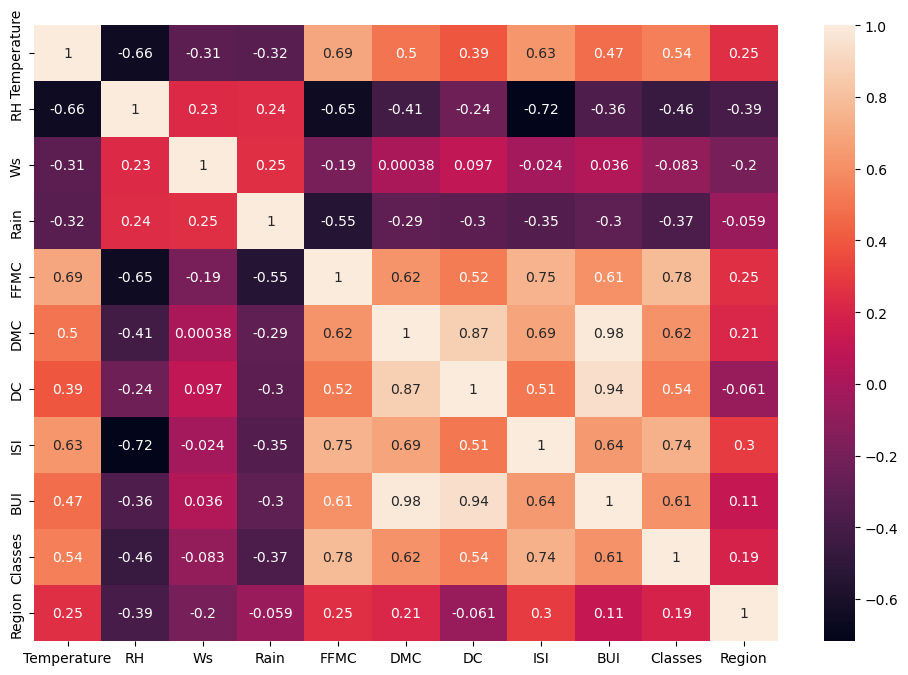

In [34]:
## Check for multiCollinearity
plt.figure(figsize=(12,8))
corr=X_train.corr()
sns.heatmap(corr,annot=True)

In [35]:
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of deleted columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [43]:
# threshold is set by domain expertise

corr_features=correlation(X_train,0.85)


In [44]:
# drop these features when correlation is more than .85
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape,X_test.shape

((182, 8), (61, 8))

### Feature Scaling or Standardization

In [ ]:

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

### Box plots to understand the effects of standrd scaler

Text(0.5, 1.0, 'After Scaling')

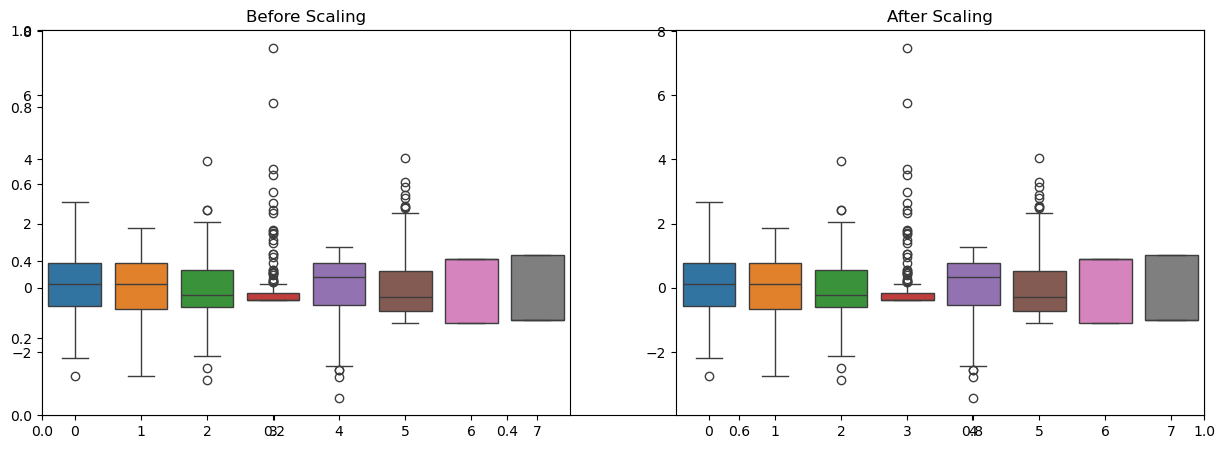

In [49]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title("Before Scaling")
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title("After Scaling")

### Linear Regression Model

MAE: 1.8401828140965233
MSE: 6.404924097026127
R2 Score: 0.855290430653149


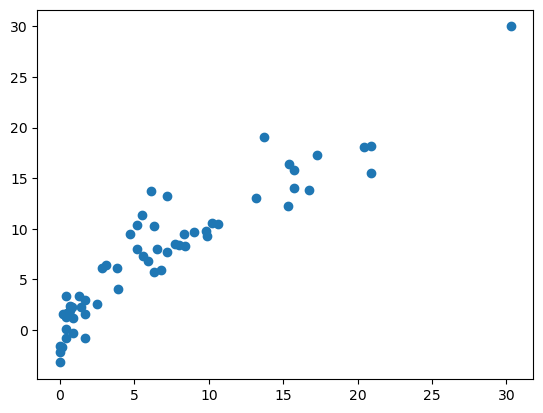

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred=linreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MAE:",mae)
print("MSE:",mse)
print("R2 Score:",r2)
plt.scatter(y_test,y_pred)

### Lasso Regression Model

MAE: 2.180930193491037
MSE: 8.023932281563685
R2 Score: 0.8187113902766614


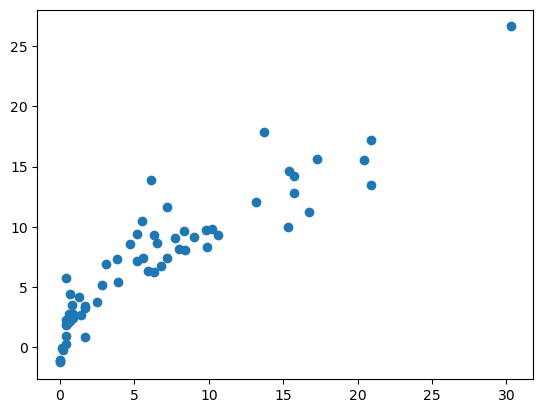

In [ ]:

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
Lasso=Lasso()
Lasso.fit(X_train_scaled,y_train)
y_pred=Lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MAE:",mae)
print("MSE:",mse)
print("R2 Score:",r2)
plt.scatter(y_test,y_pred)

### Ridge Regression Model

MAE: 1.8487582625894419
MSE: 6.407617922004764
R2 Score: 0.8552295677535035


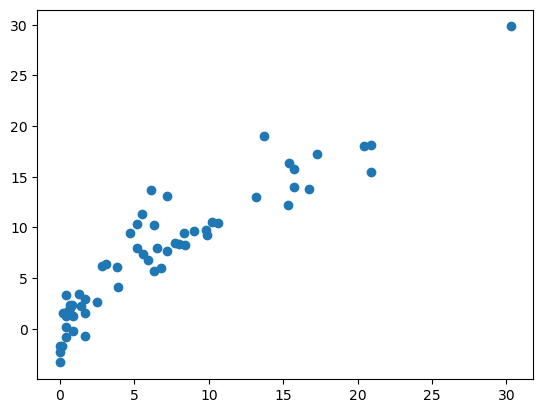

In [53]:

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
Ridge=Ridge()
Ridge.fit(X_train_scaled,y_train)
y_pred=Ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MAE:",mae)
print("MSE:",mse)
print("R2 Score:",r2)
plt.scatter(y_test,y_pred)

### Elasticnet Regression Model

MAE: 2.5985580924097404
MSE: 10.359990569275565
R2 Score: 0.7659316877129903


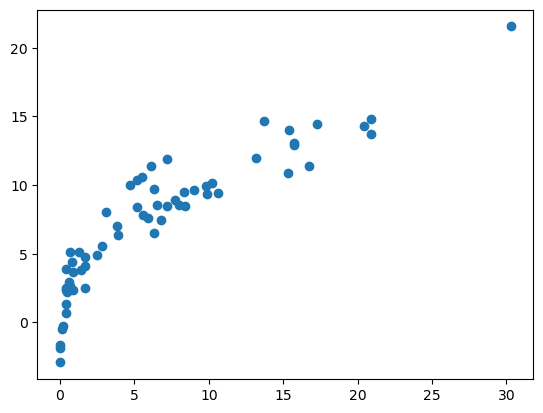

In [55]:

from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
ElasticNet=ElasticNet()
ElasticNet.fit(X_train_scaled,y_train)
y_pred=ElasticNet.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MAE:",mae)
print("MSE:",mse)
print("R2 Score:",r2)
plt.scatter(y_test,y_pred)

## Cross Validation Lasso

In [63]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)
mae=mean_absolute_error(y_test,lassocv.predict(X_test_scaled))
mse=mean_squared_error(y_test,lassocv.predict(X_test_scaled))
r2=r2_score(y_test,lassocv.predict(X_test_scaled))
print("MAE:",mae)
print("MSE:",mse)
print("R2 Score:",r2)

MAE: 1.855279686892515
MSE: 6.444093985562323
R2 Score: 0.8544054462855639


In [58]:
lassocv.alphas_

array([6.73834239, 6.28420067, 5.86066658, 5.46567726, 5.09730891,
       4.75376735, 4.43337934, 4.13458441, 3.85592726, 3.59605067,
       3.35368889, 3.12766148, 2.91686756, 2.72028045, 2.53694266,
       2.36596121, 2.20650334, 2.0577924 , 1.91910408, 1.78976289,
       1.66913886, 1.55664449, 1.45173186, 1.35388999, 1.26264234,
       1.17754447, 1.09818191, 1.02416813, 0.95514262, 0.89076921,
       0.83073434, 0.77474563, 0.72253037, 0.67383424, 0.62842007,
       0.58606666, 0.54656773, 0.50973089, 0.47537673, 0.44333793,
       0.41345844, 0.38559273, 0.35960507, 0.33536889, 0.31276615,
       0.29168676, 0.27202805, 0.25369427, 0.23659612, 0.22065033,
       0.20577924, 0.19191041, 0.17897629, 0.16691389, 0.15566445,
       0.14517319, 0.135389  , 0.12626423, 0.11775445, 0.10981819,
       0.10241681, 0.09551426, 0.08907692, 0.08307343, 0.07747456,
       0.07225304, 0.06738342, 0.06284201, 0.05860667, 0.05465677,
       0.05097309, 0.04753767, 0.04433379, 0.04134584, 0.03855

In [59]:
lassocv.mse_path_

array([[50.8129891 , 65.39074075, 52.50462315, 77.90299066, 41.59867037],
       [46.42020879, 61.07250415, 47.76817751, 77.90299066, 36.54285826],
       [42.55461285, 55.23199904, 43.60446554, 72.6661576 , 32.24150621],
       [39.15056645, 50.12622899, 39.94186658, 64.90148444, 28.58987932],
       [36.15077949, 45.66124608, 36.71788789, 58.20804626, 25.49732026],
       [33.50523339, 41.75522116, 33.87798925, 52.44227801, 22.88538634],
       [31.17024684, 38.33687326, 31.3745598 , 47.47082777, 20.6862311 ],
       [29.10766237, 35.34410314, 29.16602717, 43.12569917, 18.84119861],
       [27.28413797, 32.54005019, 27.21608202, 39.36488027, 17.29960259],
       [25.67053035, 29.85822503, 25.15628103, 36.11095944, 15.60204808],
       [23.83652672, 27.50835743, 23.14217258, 33.29616581, 14.0386773 ],
       [21.98631065, 25.36473489, 21.36936063, 30.86338515, 12.67741293],
       [20.2622302 , 23.33966022, 19.80772499, 28.76131608, 11.53739188],
       [18.47661064, 21.55972083, 18.3

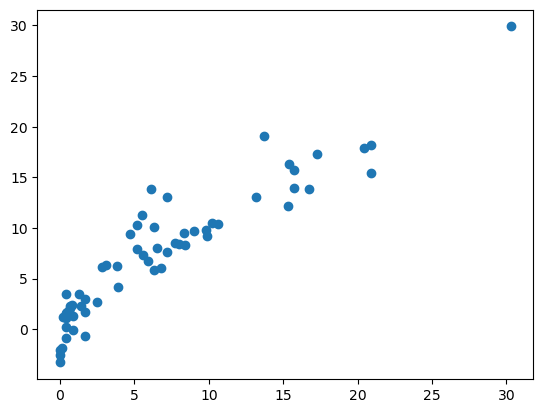

In [69]:
y_pred=lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)

# Cross Validation Ridge

MAE: 1.8487582625894419
MSE: 6.407617922004764
R2 Score: 0.8552295677535035


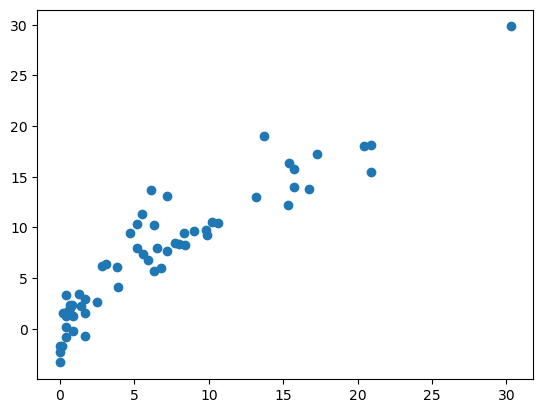

In [70]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
plt.scatter(y_test,ridgecv.predict(X_test_scaled))
mae=mean_absolute_error(y_test,ridgecv.predict(X_test_scaled))
mse=mean_squared_error(y_test,ridgecv.predict(X_test_scaled))
r2=r2_score(y_test,ridgecv.predict(X_test_scaled))
print("MAE:",mae)
print("MSE:",mse)
print("R2 Score:",r2)

In [72]:
ridgecv.alphas

(0.1, 1.0, 10.0)

In [74]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

## Elastic Net Cross Validation

MAE: 1.8590441252455658
MSE: 6.427439655254466
R2 Score: 0.8552295677535035


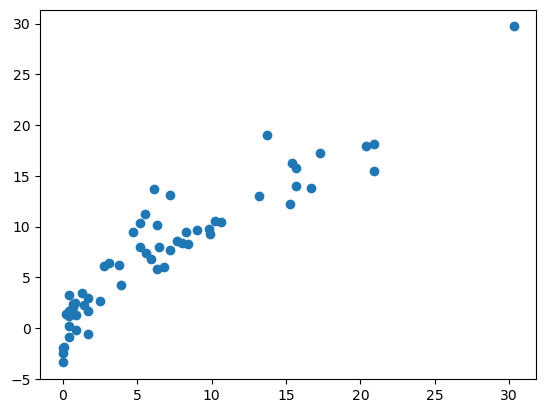

In [75]:
from sklearn.linear_model import ElasticNetCV
elasticnetcv=ElasticNetCV(cv=5)
elasticnetcv.fit(X_train_scaled,y_train)
plt.scatter(y_test,elasticnetcv.predict(X_test_scaled))
mae=mean_absolute_error(y_test,elasticnetcv.predict(X_test_scaled))
mse=mean_squared_error(y_test,elasticnetcv.predict(X_test_scaled))
r2=r2_score(y_test,ridgecv.predict(X_test_scaled))
print("MAE:",mae)
print("MSE:",mse)
print("R2 Score:",r2)

In [76]:
elasticnetcv.alphas_

array([13.47668479, 12.56840134, 11.72133315, 10.93135453, 10.19461782,
        9.5075347 ,  8.86675868,  8.26916882,  7.71185452,  7.19210133,
        6.70737777,  6.25532296,  5.83373513,  5.44056091,  5.07388531,
        4.73192242,  4.41300669,  4.11558481,  3.83820817,  3.57952578,
        3.33827772,  3.11328898,  2.90346372,  2.70777998,  2.52528468,
        2.35508894,  2.19636383,  2.04833626,  1.91028525,  1.78153842,
        1.66146869,  1.54949126,  1.44506074,  1.34766848,  1.25684013,
        1.17213332,  1.09313545,  1.01946178,  0.95075347,  0.88667587,
        0.82691688,  0.77118545,  0.71921013,  0.67073778,  0.6255323 ,
        0.58337351,  0.54405609,  0.50738853,  0.47319224,  0.44130067,
        0.41155848,  0.38382082,  0.35795258,  0.33382777,  0.3113289 ,
        0.29034637,  0.270778  ,  0.25252847,  0.23550889,  0.21963638,
        0.20483363,  0.19102852,  0.17815384,  0.16614687,  0.15494913,
        0.14450607,  0.13476685,  0.12568401,  0.11721333,  0.10